## Exploratory Data Analysis of NIH-XRay14

In [1]:
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
import sys
sys.path.append("..")
from src.dataset import ChestXrayDataset
from src.utils import train_transforms


print(f"PyTorch: {torch.__version__}")

/home/dom/medical-image-classification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0+cu130


In [2]:
ds = load_dataset(
    "alkzar90/NIH-Chest-X-ray-dataset",
    "image-classification",
    split = 'train',
    cache_dir = "../data",
    trust_remote_code = True,
    )

### Exploring Hugging Face dataset structure

In [3]:
# Exploring dataset structure
print(f'Features (columns) names: {ds.features}')
print(f'Sample of record: {ds[0]}')
print(f'Total number of records: {len(ds)}')

Features (columns) names: {'image': Image(mode=None, decode=True, id=None), 'labels': Sequence(feature=ClassLabel(names=['No Finding', 'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia'], id=None), length=-1, id=None)}
Sample of record: {'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=1024x1024 at 0x751389E2E390>, 'labels': [2]}
Total number of records: 78827


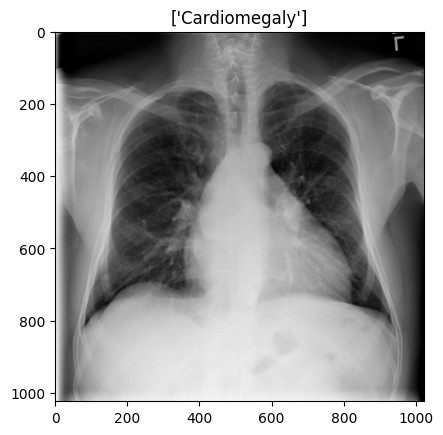

In [6]:
# Showing sample image and label
class_names = ds.features["labels"].feature.names
plt.imshow(ds[0]["image"], cmap="gray")
plt.title([class_names[i] for i in ds[0]["labels"]])
plt.show()

### Label distribution

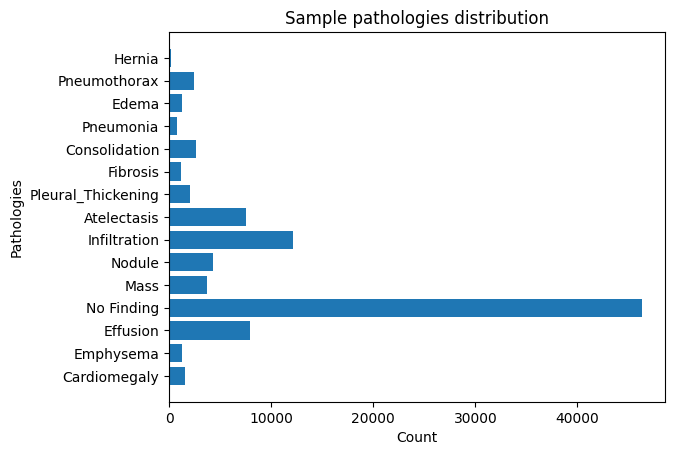

<Figure size 2000x1500 with 0 Axes>

In [7]:

all_labels = ds["labels"]
count = Counter()
for labels in all_labels:
    count.update(labels)

class_name = [class_names[cls] for cls in count.keys()]
plt.barh(class_name, count.values())
plt.xlabel('Count')
plt.ylabel('Pathologies')
plt.title('Sample pathologies distribution')
plt.figure(figsize=(20,15))
plt.show()



#### Finding
The bar chart shows that the dataset has a high proportion of negative examples with no pathologies and a small portion of images with pathologies. This will need to be considered in the choice of evaluation metric to reflect the correct distribution and effectiveness of model. Additionally, some images may have multiple pathologies since the total label count is higher than 5000 (number of samples). Therefore, this shows that the classification model will need to predict pathologies that are not mutually exclusive. 

### Number of Labels per Image Distribution

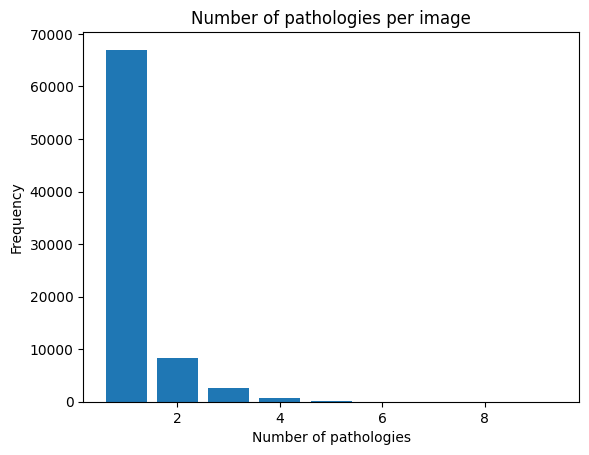

In [10]:
# Number of labels per image
multi_label_count = Counter(len(labels) for labels in all_labels)
plt.bar(multi_label_count.keys(), multi_label_count.values())
plt.title("Number of pathologies per image")
plt.xlabel("Number of pathologies")
plt.ylabel("Frequency")
plt.show()

#### Finding
More than 80% of the images have a single pathology detected, and more than 80% of those are "No finding". Hence, it is important that the model can learn and detect multi-label cases and that "Accuracy" should not be the metric used for evaluation of model performance. 

### All dataset class visualization

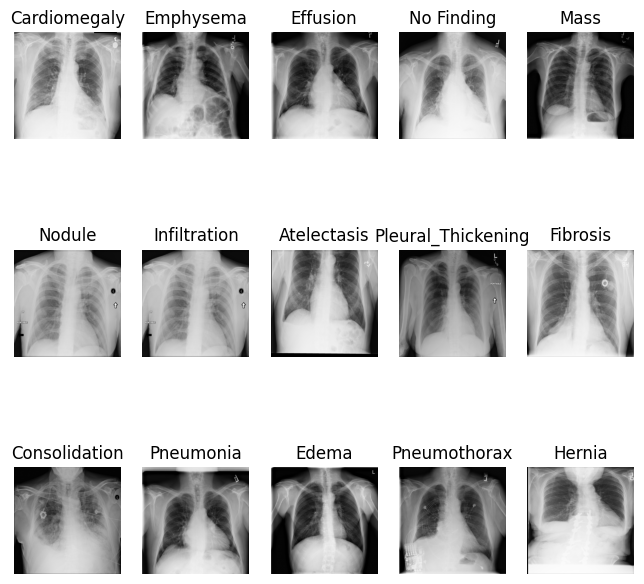

In [11]:
# Visualizing the dataset
figure = plt.figure(figsize=(8,8))
cols, rows = 5, 3
for i in range(len(class_names)):
    for j in range(len(ds)):
        if i in ds[j]["labels"]:
            figure.add_subplot(rows, cols, i + 1)
            plt.title(class_name[i])
            plt.axis("off")
            plt.imshow(ds[j]["image"], cmap="gray")
            break
plt.show()
            


### Transform Hugging Face dataset to Pytorch Custom Dataset with Augmentation for train data

In [12]:
dataset = ChestXrayDataset(ds, transform=train_transforms)
image, label = dataset[50]
print(image.shape)
print(label.shape)
print(label)

torch.Size([3, 224, 224])
torch.Size([14])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])
